# 1: Setup and Package Import

In [1]:
import openmc
# import openmc.plotter
import paramak
from cad_to_dagmc import CadToDagmc
from pathlib import Path
from IPython.display import Image, display # For displaying plots
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import neutronics_material_maker as nmm
import pyvista as pv
import pandas as pd

import os
import sys
from contextlib import contextmanager

@contextmanager
def quiet():
    """
    Silences both Python-level and C-level (OS) output.
    Works in Jupyter Notebooks for libraries like Gmsh/OpenMC.
    """
    # Open a pair of null files
    null_fds = [os.open(os.devnull, os.O_RDWR) for x in range(2)]

    # Save the actual stdout (1) and stderr (2) file descriptors.
    save_fds = [os.dup(1), os.dup(2)]

    try:
        # Redirect the actual stdout/stderr to the null files
        os.dup2(null_fds[0], 1)
        os.dup2(null_fds[1], 2)

        yield
    finally:
        # Restore the original file descriptors
        os.dup2(save_fds[0], 1)
        os.dup2(save_fds[1], 2)

        # Close the duplicate handles
        for fd in null_fds + save_fds:
            os.close(fd)

# --- Step 0: Setup ---
# Set path for cross-sections.
openmc.config['cross_sections'] = Path.home() / 'nuclear_data' / 'cross_sections.xml'
print(f"Set openmc.config['cross_sections'] to {openmc.config['cross_sections']}")

# --- NEW: Define and create the output directory ---
output_dir = Path.cwd().parent / "outputs"
print(output_dir)
output_dir.mkdir(parents=True, exist_ok=True)
print(f"All outputs will be saved to: {output_dir}")

Set openmc.config['cross_sections'] to /home/vk/nuclear_data/cross_sections.xml
/home/vk/fusion-neutronics-modelling/outputs
All outputs will be saved to: /home/vk/fusion-neutronics-modelling/outputs


# 2: Paramak Model

In [2]:
# --- 1. Global Component Dictionary ---
# Maps layer ID to ((R,G,B,A), "Nicer Name")
# This is now the single source of truth for colors and names.

COMPONENT_MAP = {
    'layer_1': ((0.1, 0.6, 0.1), "centre_column"),
    'layer_2': ((0.7, 0.7, 0.7), "magnet_shield"),
    'layer_3': ((0.9, 0.1, 0.1), "first_wall"),
    'layer_4': ((0.1, 0.1, 0.9), "breeder"),
    'layer_5': ((1.0, 0.7, 0.0), "rear_wall"),
    'plasma':  ((1.0, 0.2, 0.8, 0.6), "plasma"),
}

paramak_colors = {
    name: details[0] for name, details in COMPONENT_MAP.items()
}

In [ ]:
def basic_tokamak(paramak_colors, blanket_thickness = (100), t = 0.55, rot_angle = 90, first_wall_thickness = 100):

    # RADIAL BUILD (Inside -> Outside)
    # Paramak assigns layer_N names to SOLID types in order of appearance.
    radial_build_list = [
        (paramak.LayerType.GAP, 10),                # Inner bore / Gap
        (paramak.LayerType.SOLID, 30),              # layer_1: centre_column
        (paramak.LayerType.SOLID, 50),              # layer_2: magnet_shield
        (paramak.LayerType.SOLID, 10),              # layer_3: rear_wall (Inboard)
        (paramak.LayerType.SOLID, (blanket_thickness/100)*(2/3)*70),# layer_4: breeder (Inboard)
        (paramak.LayerType.SOLID, (first_wall_thickness / 100) * 3),              # layer_5: first_wall (Inboard)
        (paramak.LayerType.GAP, 60),                # Gap for Plasma (Inboard side)
        (paramak.LayerType.PLASMA, 300),            # The Plasma
        (paramak.LayerType.GAP, 60),                # Gap for Plasma (Outboard side)
        (paramak.LayerType.SOLID, (first_wall_thickness / 100) * 3),              # layer_3: first_wall (Outboard)
        (paramak.LayerType.SOLID, (blanket_thickness/100)*(2/3)*110),# layer_4: breeder (Outboard)
        (paramak.LayerType.SOLID, 10),              # layer_5: rear_wall (Outboard)
    ]

    # VERTICAL BUILD
    # Note: In basic Paramak shapes, vertical layers often map to the
    # corresponding radial layers (blanket components wrapping around).
    vertical_build_list = [
        (paramak.LayerType.SOLID, 15),              # layer_3: rear_wall (Lower)
        (paramak.LayerType.SOLID, (blanket_thickness/100)*(2/3)*80),# layer_4: breeder (Lower)
        (paramak.LayerType.SOLID, (first_wall_thickness / 100) * 2),              # layer_5: first_wall (Lower)
        (paramak.LayerType.GAP, 50),                # Gap
        (paramak.LayerType.PLASMA, 700),            # Plasma Elongation
        (paramak.LayerType.GAP, 60),                # Gap
        (paramak.LayerType.SOLID, (first_wall_thickness / 100) * 2),              # layer_3: first_wall (Upper)
        (paramak.LayerType.SOLID, (blanket_thickness/100)*(2/3)*40),# layer_4: breeder (Upper)
        (paramak.LayerType.SOLID, 15),              # layer_5: rear_wall (Upper)
    ]

    my_reactor = paramak.tokamak(
        radial_build=radial_build_list,
        vertical_build=vertical_build_list,
        triangularity=t,
        rotation_angle=rot_angle,
        colors=paramak_colors
    )

    reactor_material_tags = my_reactor.names()
    reactor_material_tags[2] = 'eurofer' # required to ensure that the EUROFER first wall is properly parsed


    return (my_reactor, reactor_material_tags, radial_build_list)



Execution Cell ↓

In [23]:
my_reactor, reactor_material_tags, radial_build_list = basic_tokamak(paramak_colors)
print(reactor_material_tags)
my_reactor

['layer_1', 'layer_2', 'eurofer', 'layer_4', 'layer_5', 'plasma']


# 3: Conversion to DAGMC

In [4]:
def converter_code(my_reactor, reactor_material_tags):
    print("Converting CAD to DAGMC...")

    with quiet(): # <--- Wrap the heavy lifting here
        converter = CadToDagmc()

        # Add the CadQuery assembly from the Paramak object
        converter.add_cadquery_object(
            my_reactor,
            material_tags=reactor_material_tags
        )

        h5m_filename = output_dir / "dagmc_reactor.h5m"

        # Export the DAGMC .h5m file
        converter.export_dagmc_h5m_file(
            filename=str(h5m_filename),
            max_mesh_size=20.0,
            min_mesh_size=2.0
        )
    print(f"Successfully created {h5m_filename}")

    return (h5m_filename)


Execution Cell ↓

In [28]:
h5m_filename = converter_code(my_reactor, reactor_material_tags)

written DAGMC file /home/vk/fusion-neutronics-modelling/outputs/dagmc_reactor.h5m
Successfully created /home/vk/fusion-neutronics-modelling/outputs/dagmc_reactor.h5m


# Liquid Breeder Materials List

In [7]:
Li = openmc.Material()
Li.add_element('Li',
     1,
    percent_type = 'ao',
    enrichment = 60,
    enrichment_target = 'Li6',
    enrichment_type = 'ao')
Li.set_density('g/cm3', 0.512)


Li17Pb83 = openmc.Material()
Li17Pb83.add_element('Li',
     17,
    percent_type = 'ao',
    enrichment = 60,
    enrichment_target = 'Li6',
    enrichment_type = 'ao')
Li17Pb83.add_element('Pb', 83)
Li17Pb83.set_density('g/cm3', 11)


LiF_BeF2_1 = openmc.Material()
LiF_BeF2_1.add_element('Li',
     2,
    percent_type = 'ao',
    enrichment = 60,
    enrichment_target = 'Li6',
    enrichment_type = 'ao')
LiF_BeF2_1.add_element('Be', 1)
LiF_BeF2_1.add_element('F', 4)
LiF_BeF2_1.set_density('g/cm3', 2.04)


LiF_BeF2_2 = openmc.Material()
LiF_BeF2_2.add_element('Li',
     1,
    percent_type = 'ao',
    enrichment = 60,
    enrichment_target = 'Li6',
    enrichment_type = 'ao')
LiF_BeF2_2.add_element('Be', 1)
LiF_BeF2_2.add_element('F', 3)
LiF_BeF2_2.set_density('g/cm3', 2.06)


LiF_PbF2 = openmc.Material()
LiF_PbF2.add_element('Li',
     2,
    percent_type = 'ao',
    enrichment = 60,
    enrichment_target = 'Li6',
    enrichment_type = 'ao')
LiF_PbF2.add_element('F', 8)
LiF_PbF2.add_element('Pb', 3)
LiF_PbF2.set_density('g/cm3', 3.55)


Li3N = openmc.Material()
Li3N.add_element('Li',
     3,
    percent_type = 'ao',
    enrichment = 60,
    enrichment_target = 'Li6',
    enrichment_type = 'ao')
Li3N.add_element('N', 1)
Li3N.set_density('g/cm3', 1.30)

LiF = openmc.Material()
LiF.add_element('Li',
     2,
    percent_type = 'ao',
    enrichment = 60,
    enrichment_target = 'Li6',
    enrichment_type = 'ao')
LiF.add_element('F', 1)
LiF.set_density('g/cm3', 2.64)


LiF_BeF2_NaF = openmc.Material()
LiF_BeF2_NaF.add_element('Li',
     1,
    percent_type = 'ao',
    enrichment = 60,
    enrichment_target = 'Li6',
    enrichment_type = 'ao')
LiF_BeF2_NaF.add_element('F', 4)
LiF_BeF2_NaF.add_element('Na', 1)
LiF_BeF2_NaF.add_element('Be', 1)
LiF_BeF2_NaF.set_density('g/cm3', 2.15)


LiF_NaF_ZrF4 = openmc.Material()
LiF_NaF_ZrF4.add_element('Li',
     55,
    percent_type = 'ao',
    enrichment = 60,
    enrichment_target = 'Li6',
    enrichment_type = 'ao')
LiF_NaF_ZrF4.add_element('F', 169)
LiF_NaF_ZrF4.add_element('Na', 22)
LiF_NaF_ZrF4.add_element('Zr', 23)
LiF_NaF_ZrF4.set_density('g/cm3', 2.72)


LiF_NaF_KF = openmc.Material()
LiF_NaF_KF.add_element('Li',
     46.5,
    percent_type = 'ao',
    enrichment = 60,
    enrichment_target = 'Li6',
    enrichment_type = 'ao')
LiF_NaF_KF.add_element('F', 100)
LiF_NaF_KF.add_element('Na', 11.5)
LiF_NaF_KF.add_element('K', 42)
LiF_NaF_KF.set_density('g/cm3', 2.02)


LiCl_NaCl = openmc.Material()
LiCl_NaCl.add_element('Li',
     72,
    percent_type = 'ao',
    enrichment = 60,
    enrichment_target = 'Li6',
    enrichment_type = 'ao')
LiCl_NaCl.add_element('Cl', 100)
LiCl_NaCl.add_element('Na', 28)
LiCl_NaCl.set_density('g/cm3', 1.52)


LiCl_KCl_1 = openmc.Material()
LiCl_KCl_1.add_element('Li',
     7,
    percent_type = 'ao',
    enrichment = 60,
    enrichment_target = 'Li6',
    enrichment_type = 'ao')
LiCl_KCl_1.add_element('Cl', 10)
LiCl_KCl_1.add_element('K', 3)
LiCl_KCl_1.set_density('g/cm3', 1.51)


LiCl_KCl_2 = openmc.Material()
LiCl_KCl_2.add_element('Li',
     52,
    percent_type = 'ao',
    enrichment = 60,
    enrichment_target = 'Li6',
    enrichment_type = 'ao')
LiCl_KCl_2.add_element('Cl', 100)
LiCl_KCl_2.add_element('K',48)
LiCl_KCl_2.set_density('g/cm3', 1.51)


LiCl_BeCl2 = openmc.Material()
LiCl_BeCl2.add_element('Li',
     1,
    percent_type = 'ao',
    enrichment = 60,
    enrichment_target = 'Li6',
    enrichment_type = 'ao')
LiCl_BeCl2.add_element('Cl', 3)
LiCl_BeCl2.add_element('Be',1)
LiCl_BeCl2.set_density('g/cm3', 1.52)


LiF_LiI2 = openmc.Material()
LiF_LiI2.add_element('Li',
     100,
    percent_type = 'ao',
    enrichment = 60,
    enrichment_target = 'Li6',
    enrichment_type = 'ao')
LiF_LiI2.add_element('F', 83.5)
LiF_LiI2.add_element('I',33)
LiF_LiI2.set_density('g/cm3', 3.68)


LiCl_PbCl2 = openmc.Material()
LiCl_PbCl2.add_element('Li',
     1,
    percent_type = 'ao',
    enrichment = 60,
    enrichment_target = 'Li6',
    enrichment_type = 'ao')
LiCl_PbCl2.add_element('Pb', 2)
LiCl_PbCl2.add_element('Cl',5)
LiCl_PbCl2.set_density('g/cm3', 4.50)


LiF_LiBr_NaF = openmc.Material()
LiF_LiBr_NaF.add_element('Li',
     93,
    percent_type = 'ao',
    enrichment = 60,
    enrichment_target = 'Li6',
    enrichment_type = 'ao')
LiF_LiBr_NaF.add_element('F', 21)
LiF_LiBr_NaF.add_element('Br',79)
LiF_LiBr_NaF.add_element('Na',7)
LiF_LiBr_NaF.set_density('g/cm3', 3.20)


LiF_LiBr_NaBr = openmc.Material()
LiF_LiBr_NaBr.add_element('Li',
     93,
    percent_type = 'ao',
    enrichment = 60,
    enrichment_target = 'Li6',
    enrichment_type = 'ao')
LiF_LiBr_NaBr.add_element('F', 20)
LiF_LiBr_NaBr.add_element('Br',80)
LiF_LiBr_NaBr.add_element('Na',7)
LiF_LiBr_NaBr.set_density('g/cm3', 3.16)


liquid_breeders = [Li, Li17Pb83, LiF_BeF2_1, LiF_BeF2_2, LiF_PbF2, Li3N, LiF, LiF_BeF2_NaF, LiF_NaF_ZrF4, LiF_NaF_KF, LiCl_NaCl, LiCl_KCl_1, LiCl_KCl_2, LiCl_BeCl2, LiF_LiI2, LiCl_PbCl2, LiF_LiBr_NaF, LiF_LiBr_NaBr]
liquid_names = ['Li', 'Li17Pb83', 'LiF_BeF2', 'Li_BeF2*', 'LiF_PbF2', 'Li3N', 'LiF', 'LiF_BeF2_NaF', 'LiF_NaF_ZrF4', 'LiF_NaF_KF', 'LiCl_NaCl', 'LiCl_KCl', 'LiCl_KCl*', 'LiCl_BeCl2', 'LiF_LiI2', 'LiCl_PbCl2', 'LiF_LiBr_NaF', 'LiF_LiBr_NaBr']

# Solid Breeder Materials List

In [ ]:

Li2O = nmm.Material(
    name="Li2O",
    density=2.1,
    density_unit="g/cm3",
    percent_type="ao",
    packing_fraction = 0.64,
    elements={
            "Li": 1,
            "O": 2
            },
    enrichment = 60,  enrichment_target = 'Li6', enrichment_type = 'ao'
    ).openmc_material

Li4SiO4 = nmm.Material(
    name="Li4SiO4",
    density=2.4,
    density_unit="g/cm3",
    percent_type="ao",
    packing_fraction = 0.64,
    elements={
            "Li": 4,
            "O": 4,
            "Si": 1
            },
    enrichment = 60,  enrichment_target = 'Li6', enrichment_type = 'ao'
    ).openmc_material

Li2TiO3 = nmm.Material(
    name="Li2TiO3",
    density=3.43,
    density_unit="g/cm3",
    percent_type="ao",
    packing_fraction = 0.64,
    elements={
            "Li": 2,
            "O": 3,
            "Ti": 1
            },
    enrichment = 60,  enrichment_target = 'Li6', enrichment_type = 'ao'
    ).openmc_material


Li8PbO6 = nmm.Material(
    name="Li8PbO6",
    density=4.28,
    density_unit="g/cm3",
    percent_type="ao",
    packing_fraction = 0.64,
    elements={
            "Li": 8,
            "O": 6,
            "Pb": 1
            },
    enrichment = 60,  enrichment_target = 'Li6', enrichment_type = 'ao'
    ).openmc_material


Li8SiO6 = nmm.Material(
    name="Li8SiO6",
    density=2.2,
    density_unit="g/cm3",
    percent_type="ao",
    packing_fraction = 0.64,
    elements={
            "Li": 8,
            "O": 6,
            "Si": 1
            },
    enrichment = 60,  enrichment_target = 'Li6', enrichment_type = 'ao'
    ).openmc_material


Li8CoO6 = nmm.Material(
    name="Li8CoO6",
    density=2.47,
    density_unit="g/cm3",
    percent_type="ao",
    packing_fraction = 0.64,
    elements={
            "Li": 8,
            "O": 6,
            "Co": 1
            },
    enrichment = 60,  enrichment_target = 'Li6', enrichment_type = 'ao'
    ).openmc_material


Li8GeO6 = nmm.Material(
    name="Li8GeO6",
    density=2.64,
    density_unit="g/cm3",
    percent_type="ao",
    packing_fraction = 0.64,
    elements={
            "Li": 8,
            "O": 6,
            "Ge": 1
            },
    enrichment = 60,  enrichment_target = 'Li6', enrichment_type = 'ao'
    ).openmc_material


Li8ZrO6 = nmm.Material(
    name="Li8ZrO6",
    density=2.98,
    density_unit="g/cm3",
    percent_type="ao",
    packing_fraction = 0.64,
    elements={
            "Li": 8,
            "O": 6,
            "Zr": 1
            },
    enrichment = 60,  enrichment_target = 'Li6', enrichment_type = 'ao'
    ).openmc_material


Li8SnO6 = nmm.Material(
    name="Li8SnO6",
    density=3.41,
    density_unit="g/cm3",
    percent_type="ao",
    packing_fraction = 0.64,
    elements={
            "Li": 8,
            "O": 6,
            "Sn": 1
            },
    enrichment = 60,  enrichment_target = 'Li6', enrichment_type = 'ao'
    ).openmc_material


Li8CeO6 = nmm.Material(
    name="Li8CeO6",
    density=3.25,
    density_unit="g/cm3",
    percent_type="ao",
    packing_fraction = 0.64,
    elements={
            "Li": 8,
            "O": 6,
            "Ce": 1
            },
    enrichment = 60,  enrichment_target = 'Li6', enrichment_type = 'ao'
    ).openmc_material


Li6MnO4 = nmm.Material(
    name="Li6MnO4",
    density=2.50,
    density_unit="g/cm3",
    percent_type="ao",
    packing_fraction = 0.64,
    elements={
            "Li": 6,
            "O": 4,
            "Mn": 1
            },
    enrichment = 60,  enrichment_target = 'Li6', enrichment_type = 'ao'
    ).openmc_material


Li6CoO4 = nmm.Material(
    name="Li6CoO4",
    density=2.77,
    density_unit="g/cm3",
    percent_type="ao",
    packing_fraction = 0.64,
    elements={
            "Li": 6,
            "O": 4,
            "Co": 1
            },
    enrichment = 60,  enrichment_target = 'Li6', enrichment_type = 'ao'
    ).openmc_material


Li6ZnO4 = nmm.Material(
    name="Li6ZnO4",
    density=2.86,
    density_unit="g/cm3",
    percent_type="ao",
    packing_fraction = 0.64,
    elements={
            "Li": 6,
            "O": 4,
            "Zn": 1
            },
    enrichment = 60,  enrichment_target = 'Li6', enrichment_type = 'ao'
    ).openmc_material


Li6Zr2O7 = nmm.Material(
    name="Li6Zr2O7",
    density=3.56,
    density_unit="g/cm3",
    percent_type="ao",
    packing_fraction = 0.64,
    elements={
            "Li": 6,
            "O": 7,
            "Zr": 2
            },
    enrichment = 60,  enrichment_target = 'Li6', enrichment_type = 'ao'
    ).openmc_material


Li5AlO4 = nmm.Material(
    name="Li5AlO4",
    density=2.25,
    density_unit="g/cm3",
    percent_type="ao",
    packing_fraction = 0.64,
    elements={
            "Li": 5,
            "O": 4,
            "Al": 1
            },
    enrichment = 60,  enrichment_target = 'Li6', enrichment_type = 'ao'
    ).openmc_material


Li5FeO4 = nmm.Material(
    name="Li5eO4",
    density=2.64,
    density_unit="g/cm3",
    percent_type="ao",
    packing_fraction = 0.64,
    elements={
            "Li": 5,
            "O": 4,
            "Fe": 1
            },
    enrichment = 60,  enrichment_target = 'Li6', enrichment_type = 'ao'
    ).openmc_material


Li4TiO4 = nmm.Material(
    name="Li4TiO4",
    density=2.57,
    density_unit="g/cm3",
    percent_type="ao",
    packing_fraction = 0.64,
    elements={
            "Li": 4,
            "O": 4,
            "Ti": 1
            },
    enrichment = 60,  enrichment_target = 'Li6', enrichment_type = 'ao'
    ).openmc_material


Li4GeO4 = nmm.Material(
    name="Li4GeO4",
    density=3.16,
    density_unit="g/cm3",
    percent_type="ao",
    packing_fraction = 0.64,
    elements={
            "Li": 4,
            "O": 4,
            "Ge": 1
            },
    enrichment = 60,  enrichment_target = 'Li6', enrichment_type = 'ao'
    ).openmc_material


Li2SiO3 = nmm.Material(
    name="Li2SiO3",
    density=2.53,
    density_unit="g/cm3",
    percent_type="ao",
    packing_fraction = 0.64,
    elements={
            "Li": 2,
            "O": 3,
            "Si": 1
            },
    enrichment = 60,  enrichment_target = 'Li6', enrichment_type = 'ao'
    ).openmc_material


Li2MnO2 = nmm.Material(
    name="Li2MnO2",
    density=3.9,
    density_unit="g/cm3",
    percent_type="ao",
    packing_fraction = 0.64,
    elements={
            "Li": 2,
            "O": 2,
            "Mn": 1
            },
    enrichment = 60,  enrichment_target = 'Li6', enrichment_type = 'ao'
    ).openmc_material





solid_breeders = [Li2O, Li4SiO4, Li2TiO3, Li8PbO6, Li8SiO6, Li8CoO6, Li8GeO6, Li8ZrO6, Li8SnO6, Li8CeO6, Li6MnO4, Li6CoO4, Li6ZnO4, Li6Zr2O7, Li5AlO4, Li5FeO4, Li4TiO4, Li4GeO4, Li2SiO3, Li2MnO2]
solid_names = ['Li2O', 'Li4SiO4', 'Li2TiO3', 'Li8PbO6', 'Li8SiO6', 'Li8CoO6', 'Li8GeO6', 'Li8ZrO6', 'Li8SnO6', 'Li8CeO6', 'Li6MnO4', 'Li6CoO4', 'Li6ZnO4', 'Li6Zr2O7', 'Li5AlO4', 'Li5FeO4', 'Li4TiO4', 'Li4GeO4', 'Li2SiO3', 'Li2MnO2']

# 4: Define Materials (One Material)

In [ ]:
def materials_library(reactor_material_tags, enrichment = 60, coolant_fraction = 0.36, pb_fraction = 83):
    # --- RESET AUTO IDs ---
    # This resets the internal counters for Material, Cell, and Surface IDs
    # to prevent them from increasing every time the cell is re-run.
    openmc.reset_auto_ids()
    # --------------------
    eurofer_mat = nmm.Material.from_library('eurofer')

    materials_list = []

    eurofer_mat = nmm.Material.from_library('eurofer')

    for tag in reactor_material_tags:
        # Create a new material with the *exact* name as the tag
        mat = openmc.Material(name=tag)

    # In a real model, you'd add specific elements based on the tag
    # The 'paramak.tokamak' builder tags the plasma as 'plasma'
    # and other layers as 'radial_layer_1', 'vertical_layer_1' etc.
        if tag == 'plasma':
            mat.add_nuclide('H3', 1.0, 'ao')
            mat.add_nuclide('H2', 1.0, 'ao')  # Dummy plasma
            mat.set_density('g/cm3', 1.0e-9)
        elif tag == 'layer_4':

            breeder = openmc.Material()
            breeder.add_element(
                'Li',
                17,
                percent_type = 'ao',
                enrichment = enrichment,
                enrichment_target = 'Li6',
                enrichment_type = 'ao')
            breeder.add_element('Pb', 83, 'ao')
            breeder.set_density('g/cm3', 11)

            # ------------------ Non Eutectic Multiplier Sweep Material ------------------ #
            # breeder = openmc.Material()
            # breeder.add_element(
            #     'Li',
            #     100-pb_fraction,
            #     percent_type = 'ao',
            #     enrichment = enrichment,
            #     enrichment_target = 'Li6',
            #     enrichment_type = 'ao')
            # breeder.add_element('Pb', pb_fraction, 'ao')
            # breeder.set_density('g/cm3', ((11.33*pb_fraction)+(0.512*(100-pb_fraction)))/100)

            my_mat = nmm.Material(
                name="LiPb Vac",
                density=11,
                density_unit="g/cm3",
                percent_type="ao",
                packing_fraction = 2/3,
                elements={
                        "Li": 17,
                        "Pb": 83
                        },
                enrichment = 60,  enrichment_target = 'Li6', enrichment_type = 'ao'
            ).openmc_material

            multiplier = openmc.Material()
            multiplier.add_element('Be', 12, 'ao')
            multiplier.add_element('Ti', 1, 'ao')
            multiplier.set_density('g/cm3', 2.28)

            coolant_he = nmm.Material.from_library(
                'He',
                temperature=800,
                pressure=8000000
            ).openmc_material

            coolant_h2o = nmm.Material.from_library(
                'H2O',
                temperature=600,
                pressure=15500000
            ).openmc_material

            coolant_n2 = nmm.Material.from_library(
                'nitrogen',
                temperature=600,
                pressure=1000000
            ).openmc_material

            enriched_water = openmc.Material()
            enriched_water.add_nuclide('H1', 2, 'ao')
            enriched_water.add_nuclide('O16', 1, 'ao')
            enriched_water.set_density('g/cm3', 0.6611374655967136)

            mat = openmc.Material.mix_materials(
                materials=[breeder, coolant_h2o], fracs=[1-coolant_fraction, coolant_fraction],
                percent_type='vo', name = 'layer_4'
            )

        elif tag == 'eurofer': #First Wall
            mat.add_element('Zr', 0.9809, 'ao') # Fusion Zirconium Allowy
            mat.add_element('Sn', 0.015, 'ao')
            mat.add_element('Fe', 0.002, 'ao')
            mat.add_element('Cr', 0.001, 'ao')
            mat.add_element('O', 0.0011, 'ao')
            mat.set_density('g/cm3', 6.56)

            #mat.add_element('V', 0.92, 'ao') # Fusion Vanadium Alloy
            #mat.add_element('Cr', 0.04, 'ao')
            #mat.add_element('Ti', 0.04, 'ao')
            #mat.set_density('g/cm3', 6.05)

            #mat.add_element('Si', 1, 'ao') # Fusion SiC material
            #mat.add_element('C', 1, 'ao')
            #mat.set_density('g/cm3', 2.7)

            #mat = eurofer_mat.openmc_material # For Eurofer



        else:
            # Eurofer 97, can't get library import to work
            mat.add_element('Fe', 1, 'ao')
            mat.set_density('g/cm3', 7.8)

        materials_list.append(mat)

    # Create the final Materials collection
    my_materials = openmc.Materials(materials_list)




    return (my_materials, materials_list)





Execution Cell ↓

In [10]:
my_materials, materials_list = materials_library(reactor_material_tags)


# Definition Function for List of Materials

Function to be used when running simulations for many materials.

In [9]:
def materials_listings(reactor_material_tags, c = 0.36, b_mat = Li17Pb83):

    eurofer_mat = nmm.Material.from_library('eurofer')

    materials_list = []

    for tag in reactor_material_tags:
        # Create a new material with the *exact* name as the tag
        mat = openmc.Material(name=tag)

    # In a real model, you'd add specific elements based on the tag
    # The 'paramak.tokamak' builder tags the plasma as 'plasma'
    # and other layers as 'radial_layer_1', 'vertical_layer_1' etc.
        if tag == 'plasma':
            mat.add_nuclide('H3', 1.0, 'ao')
            mat.add_nuclide('H2', 1.0, 'ao')  # Dummy plasma
            mat.set_density('g/cm3', 1.0e-9)
        elif tag == 'layer_4':

            #breeder = openmc.Material()
            #breeder.add_element(
                #'Li',
                #0.17,
                #percent_type='ao',
                #enrichment=e,
                #enrichment_target='Li6',
                #enrichment_type='ao')
            #breeder.add_element('Pb', 0.83, 'ao')
            #breeder.set_density('g/cm3', 11)

            breeder = b_mat

            multiplier = openmc.Material()
            multiplier.add_element('Be', 12, 'ao')
            multiplier.add_element('Ti', 1, 'ao')
            multiplier.set_density('g/cm3', 2.28)

            coolant_he = nmm.Material.from_library(
                'He',
                temperature=800,
                pressure=8000000
            ).openmc_material

            coolant_h2o = nmm.Material.from_library(
                'H2O',
                temperature=600,
                pressure=15500000
            ).openmc_material

            coolant_n2 = nmm.Material.from_library(
                'nitrogen',
                temperature=600,
                pressure=1000000
            ).openmc_material

            enriched_water = openmc.Material()
            enriched_water.add_nuclide('H1', 2, 'ao')
            enriched_water.add_nuclide('O16', 1, 'ao')
            enriched_water.set_density('g/cm3', 0.6611374655967136)

            mat = openmc.Material.mix_materials(
                materials=[breeder, multiplier, coolant_h2o], fracs=[0.25*(1-c), 0.75*(1-c),  c], percent_type='vo', name = 'layer_4'
            )

        elif tag == 'eurofer': #First Wall
            mat.add_element('Zr', 0.9809, 'ao') # Fusion Zirconium Allowy
            mat.add_element('Sn', 0.015, 'ao')
            mat.add_element('Fe', 0.002, 'ao')
            mat.add_element('Cr', 0.001, 'ao')
            mat.add_element('O', 0.0011, 'ao')
            mat.set_density('g/cm3', 6.56)

            #mat.add_element('V', 0.92, 'ao') # Fusion Vanadium Alloy
            #mat.add_element('Cr', 0.04, 'ao')
            #mat.add_element('Ti', 0.04, 'ao')
            #mat.set_density('g/cm3', 6.05)

            #mat.add_element('Si', 1, 'ao') # Fusion SiC material
            #mat.add_element('C', 1, 'ao')
            #mat.set_density('g/cm3', 2.7)

            #mat = eurofer_mat.openmc_material # For Eurofer



        else:
            # Eurofer 97, can't get library import to work
            mat.add_element('Fe', 1, 'ao')
            mat.set_density('g/cm3', 7.8)

        materials_list.append(mat)

    # Create the final Materials collection
    my_materials = openmc.Materials(materials_list)




    return (my_materials, materials_list)




Execution Cell ↓

In [17]:
my_materials_long, materials_list_long = materials_listings(reactor_material_tags)

# 5: Defining Geometry

In [10]:
max_boundary = 1500

def geometry_code(h5m_filename, max_boundary_input = 1500):
    # Create the DAGMC Universe
    dag_univ = openmc.DAGMCUniverse(
        filename=str(h5m_filename),
        auto_geom_ids=True)

    # --- CHANGE 1: Adjust boundaries for 1st Quadrant (90 degrees) ---
    # Set reflective boundaries on X=0 and Y=0 planes
    min_x = 0.0                 # CHANGED: From -max_boundary_input to 0.0
    max_x = max_boundary_input
    min_y = 0.0                 # Kept as 0.0
    max_y = max_boundary_input
    min_z = -max_boundary_input
    max_z = max_boundary_input

    # Define the bounding surfaces
    # --- CHANGE 2: Make X min surface reflective ---
    # x_min_surf = openmc.XPlane(min_x, boundary_type='reflective') # CHANGED: vacuum -> reflective
    x_max_surf = openmc.XPlane(max_x, boundary_type='vacuum')
    # y_min_surf = openmc.YPlane(min_y, boundary_type='reflective') # Kept as reflective
    y_max_surf = openmc.YPlane(max_y, boundary_type='vacuum')
    z_min_surf = openmc.ZPlane(min_z, boundary_type='vacuum')
    z_max_surf = openmc.ZPlane(max_z, boundary_type='vacuum')

    # 1. Set both cut-planes (X=0 and Y=0) to 'periodic'
    x_min_surf = openmc.XPlane(min_x, boundary_type='periodic')
    y_min_surf = openmc.YPlane(min_y, boundary_type='periodic')
    x_min_surf.periodic_surface = y_min_surf


    # Define the bounding cell
    bounding_cell = openmc.Cell(
        name='bounding_cell',
        # Region logic remains valid: +x_min & -x_max ...
        region=+x_min_surf & -x_max_surf & +y_min_surf & -y_max_surf & +z_min_surf & -z_max_surf,
        fill=dag_univ
    )

    my_geometry = openmc.Geometry([bounding_cell])

    return my_geometry


Execution Cell ↓

In [25]:
my_geometry = geometry_code(h5m_filename, max_boundary)

# 6: Settings and Source

In [11]:
def settings_code(radial_build_list, geometry, neutron_num = 5000, batch_num = 25,
                  num_pixels_per_dimension=100, rot_angle=90, mesh_bbox=None,
                  enable_energy_filter = False):
    """
    Defines OpenMC settings, source, and tallies.

    Args:
        radial_build_list: List of radial build parameters.
        geometry: The OpenMC geometry object.
        num_pixels_per_dimension: Resolution of the mesh (voxels per axis).
        rot_angle: The sector angle in degrees (e.g., 90).
        mesh_bbox: Optional tuple of coordinates for a custom mesh location.
                   Format: ([x_min, y_min, z_min], [x_max, y_max, z_max])
                   If None, creates a mesh surrounding the entire geometry.
    """
    print("Defining OpenMC settings...")

    # --- 1. Source Definition ---
    radial_build_values = [item[1] for item in radial_build_list]
    # Find plasma index safely
    plasma_layer = (paramak.LayerType.PLASMA, 300)
    # Note: Ensure this tuple matches your paramak definition exactly
    if plasma_layer in radial_build_list:
        plasma_index = radial_build_list.index(plasma_layer)
        plasma_inner_radius = sum(radial_build_values[:plasma_index])
        plasma_thickness = radial_build_values[plasma_index]
        approx_major_radius = plasma_inner_radius + (plasma_thickness / 2.0)
    else:
        # Fallback if plasma layer isn't found exactly as specified
        print("Warning: Plasma layer not found for source positioning. Using default.")
        approx_major_radius = 300.0

    print(f"Placing source at approximate major radius: {approx_major_radius} cm")

    my_source = openmc.IndependentSource()
    radius = openmc.stats.Discrete([approx_major_radius], [1])
    z_values = openmc.stats.Discrete([0], [1])

    # Calculate angle in radians based on rot_angle input
    max_radians = 2 * np.pi * (rot_angle / 360.0)
    # Adding a tiny epsilon (1e-5) to avoid particles starting exactly on the periodic boundary
    angle = openmc.stats.Uniform(a=1e-5, b=max_radians - 1e-5)

    my_source.space = openmc.stats.CylindricalIndependent(r=radius, phi=angle, z=z_values, origin=(0.0, 0.0, 0.0))
    my_source.angle = openmc.stats.Isotropic()
    my_source.energy = openmc.stats.muir(e0=14080000.0, m_rat=5, kt=20000.0)

    my_settings = openmc.Settings()
    my_settings.batches = batch_num
    my_settings.particles = neutron_num
    my_settings.run_mode = 'fixed source'
    my_settings.source = my_source

    # --- 2. Tallies and Filters ---
    tbr_cell_tally = openmc.Tally(name='tbr')
    tbr_cell_tally.scores = ['(n,Xt)']

    if enable_energy_filter:
        # print("Energy filtering ENABLED: Tallying TBR vs Neutron Energy.")
        # 1. Define the bins
        energies = np.logspace(np.log10(1E-4), np.log10(14E6), 101)

        # 2. Create the filter object
        energy_filter = openmc.EnergyFilter(energies)

        # 3. Apply the filter to the tally
        tbr_cell_tally.filters = [energy_filter]
    else:
        # print("Energy filtering DISABLED: Tallying Total TBR only.")
        # No filters applied implies a sum over all energies.
        pass

    scatter_tally = openmc.Tally(name='scattering')
    scatter_tally.scores = ['scatter']

    # --- 3. Mesh Definition (The Dynamic Part) ---

    if mesh_bbox is None:
        print("Creating mesh from full geometry domain...")
        mesh = openmc.RegularMesh().from_domain(
            geometry,
            dimension=[num_pixels_per_dimension, num_pixels_per_dimension, num_pixels_per_dimension]
        )
    else:
        print(f"Creating CUSTOM mesh with bbox: {mesh_bbox}")
        mesh = openmc.RegularMesh()
        mesh.dimension = [num_pixels_per_dimension, num_pixels_per_dimension, num_pixels_per_dimension]
        mesh.lower_left = mesh_bbox[0]  # [x_min, y_min, z_min]
        mesh.upper_right = mesh_bbox[1] # [x_max, y_max, z_max]

    mesh_filter = openmc.MeshFilter(mesh)

    tbr_mesh_tally = openmc.Tally(name="tbr_on_mesh")
    tbr_mesh_tally.filters = [mesh_filter]
    tbr_mesh_tally.scores = ["(n,Xt)"]

    tallies = openmc.Tallies([tbr_cell_tally, scatter_tally, tbr_mesh_tally])
    print("Settings defined.")

    return my_settings, tallies, mesh


Execution Cell ↓

In [ ]:
my_settings, tallies, mesh = settings_code(radial_build_list, my_geometry)

# Single Simulation

In [30]:
tbr_values = []
tbr_errors = []


print(f"Cleaning output directory: {output_dir}")
extensions_to_remove = ['*.h5', '*.h5m', '*.xml', '*.out']
files_removed = 0
for ext in extensions_to_remove:
    for f in output_dir.glob(ext):
        try:
            f.unlink()
            files_removed += 1
        except OSError as e:
            print(f"Warning: Could not remove {f.name}. Error: {e}")
print(f"Removed {files_removed} old files.")

reactor, material_tags, radial_build_list = basic_tokamak(paramak_colors)
my_geometry = geometry_code(converter_code(reactor, material_tags))

# -------------------------------- NORMAL SIM -------------------------------- #
# settings_i, tallies_i, mesh_i = settings_code(radial_build_list, my_geometry,
#                                               num_pixels_per_dimension=100)

# ------------------------------- ZOOMED IN SIM ------------------------------ #
#~ Define the box you want to zoom in on (e.g., outboard blanket)
## Format: ([x_min, y_min, z_min], [x_max, y_max, z_max])
zoom_box = ([550, 0, -50], [700, 50, 50])
pixel_density = 100
settings_i, tallies_i, mesh_i = settings_code(
    radial_build_list,
    my_geometry,
    neutron_num = 10000,
    batch_num = 3,
    num_pixels_per_dimension=pixel_density, # 100 voxels INSIDE that small box = super high res
    mesh_bbox=zoom_box
)


materials, materials_list = materials_library(material_tags)

my_model = openmc.Model(
    geometry=my_geometry,
    materials=materials_list,
    settings=settings_i,
    tallies=tallies_i
)

print(f"Running OpenMC in: {output_dir}")
statepoint_file = my_model.run(cwd=output_dir, output=False)
print(f"Statepoint file created: {statepoint_file}")

    # --- 3. Load statepoint file using a 'with' statement ---
    #
    #    THIS IS THE CRITICAL FIX.
    #
    #    Using 'with' ensures the statepoint file is properly closed
    #    and the file lock is released *before* the loop continues
    #    to the next iteration.
print(f"Loading statepoint: {statepoint_file} to extract results...")
with openmc.StatePoint(statepoint_file) as sp:
    tbr_cell_tally = sp.get_tally(name='tbr')

    tbr_mean = tbr_cell_tally.mean.sum()
    tbr_std_dev = tbr_cell_tally.std_dev.sum()

    tbr_values.append(tbr_cell_tally.mean)
    tbr_errors.append(tbr_cell_tally.std_dev)




    # By this point, the statepoint.10.h5 file is closed.
print(f"TBR: {tbr_mean:.4f} +/- {tbr_std_dev:.4f}")
print("--- ITERATION COMPLETED ---\n\n")


df = tbr_cell_tally.get_pandas_dataframe()
df





Cleaning output directory: /home/vk/fusion-neutronics-modelling/outputs
Removed 5 old files.
written DAGMC file /home/vk/fusion-neutronics-modelling/outputs/dagmc_reactor.h5m
Successfully created /home/vk/fusion-neutronics-modelling/outputs/dagmc_reactor.h5m
Defining OpenMC settings...
Placing source at approximate major radius: 359.66666666666663 cm
Creating CUSTOM mesh with bbox: ([550, 0, -50], [700, 50, 50])
Settings defined.
Running OpenMC in: /home/vk/fusion-neutronics-modelling/outputs
Statepoint file created: /home/vk/fusion-neutronics-modelling/outputs/statepoint.3.h5
Loading statepoint: /home/vk/fusion-neutronics-modelling/outputs/statepoint.3.h5 to extract results...
TBR: 1.5891 +/- 0.0017
--- ITERATION COMPLETED ---




,nuclide,score,mean,std. dev.
0,total,"(n,Xt)",1.589122,0.001689


### Heatmap 3D Plot

In [ ]:
# Ensure we have a statepoint file to load

print(f"Attempting to load statepoint: {statepoint_file}")

with openmc.StatePoint(statepoint_file) as sp:
    # 1. Extract the raw tally (counts per voxel)
    my_tbr_tally = sp.get_tally(name='tbr_on_mesh')

    # --- NEW CALCULATION SECTION ---
    # Instead Plot Reaction Density
    # Calculate volume of one voxel (in cm3)
    # Note: Make sure zoom_box and num_pixels_per_dimension are defined!
    # 2. Calculate Reaction Density (reactions / cm3)
    # Calculate the total width of the box in each dimension
    x_width = zoom_box[1][0] - zoom_box[0][0]
    y_width = zoom_box[1][1] - zoom_box[0][1]
    z_width = zoom_box[1][2] - zoom_box[0][2]

    # Calculate volume of a single voxel
    # Assuming mesh was created with [pixel_density, pixel_density, pixel_density]
    vox_x = x_width / pixel_density
    vox_y = y_width / pixel_density
    vox_z = z_width / pixel_density
    voxel_vol = vox_x * vox_y * vox_z

    print(f"Voxel Volume calculated as: {voxel_vol:.4f} cm3")

    # Divide the mean by volume to get Density (reactions / cm3)
    density_values = my_tbr_tally.mean / voxel_vol
    # -------------------------------

    # 2. Write the DENSITY values to VTK (instead of raw mean)
    vtk_file_path = output_dir / "tbr_tally_on_reg_mesh.vtk"

    mesh_i.write_data_to_vtk(
        filename=str(vtk_file_path),
        datasets={"reaction_density": density_values}  # Changed label to 'density'
    )

    # 3. Plotting Setup
    pv.set_jupyter_backend('html')
    mesh_plot = pv.read(str(vtk_file_path))

    # Set active scalars to the new 'density' dataset
    mesh_plot.set_active_scalars(name='reaction_density')

    # 4. Logarithmic conversion on Density
    # Get positive values from 'density' to avoid log10(0)
    positive_values = mesh_plot['reaction_density'][mesh_plot['reaction_density'] > 0]

    # Calculate log10 of density
    log_vals = np.log10(np.clip(mesh_plot['reaction_density'], a_min=positive_values.min(), a_max=None))
    mesh_plot['log(Reaction Density)'] = log_vals

    # 5. Filtering and Plotting
    # Threshold based on the new log_density values if needed, or raw density
    # Here we just set the scalar for plotting
    mesh_plot.set_active_scalars('log(Reaction Density)')

    # Optional: Filter out the super low background noise (e.g. -20)
    thresholded = mesh_plot.threshold(-15, scalars='log(Reaction Density)')

    thresholded.plot(
        show_grid=True,
        clim=[-15, -6],  # <--- UPDATE THESE: They are now log(density)
        # Example: -4 means 10^-4 reactions per cm3
        # Example: -2 means 10^-2 reactions per cm3
        cmap='inferno', # Optional: 'inferno' or 'jet' usually look better for heatmaps
        scalar_bar_args={'title': 'Log10(Reactions/cm3)'}
    )


Attempting to load statepoint: /home/vk/fusion-neutronics-modelling/outputs/statepoint.3.h5
Voxel Volume calculated as: 0.7500 cm3


EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

### Heatmap 2D Slice

Attempting to load statepoint: /home/vk/fusion-neutronics-modelling/outputs/statepoint.3.h5
Voxel Volume calculated as: 0.7500 cm3


EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

Slicing at Y = 25 cm (Index: 50)


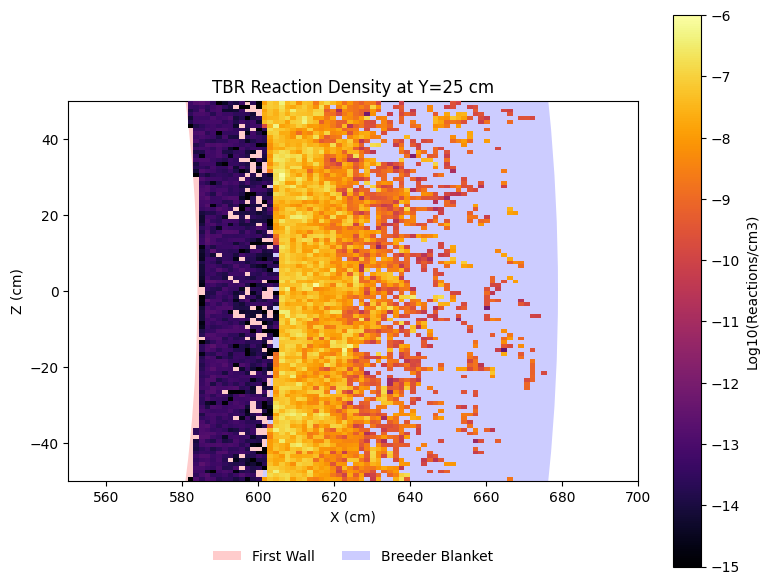

In [ ]:
import copy

print(f"Attempting to load statepoint: {statepoint_file}")

# ----------------------------- Setup Plot Slice ----------------------------- #
nx = ny = nz = pixel_density
target_y = 25
x_min, y_min, z_min = zoom_box[0]
x_max, y_max, z_max = zoom_box[1]


# ---------------------------------------------------------------------------- #
#                                 Pyvista Plot                                 #
# ---------------------------------------------------------------------------- #
with openmc.StatePoint(statepoint_file) as sp:
    # 1. Extract the raw tally (mean values)
    # Reshape to (Nz, Ny, Nx) for PyVista if needed, but 1D array often works with VTK writing
    my_tbr_tally = sp.get_tally(name='tbr_on_mesh')
    tally_mean = my_tbr_tally.mean.flatten()

    # 2. Calculate Reaction Density (reactions / cm3)
    # Calculate the total width of the box in each dimension
    x_width = zoom_box[1][0] - zoom_box[0][0]
    y_width = zoom_box[1][1] - zoom_box[0][1]
    z_width = zoom_box[1][2] - zoom_box[0][2]

    # Calculate volume of a single voxel
    # Assuming mesh was created with [pixel_density, pixel_density, pixel_density]
    vox_x = x_width / pixel_density
    vox_y = y_width / pixel_density
    vox_z = z_width / pixel_density
    voxel_vol = vox_x * vox_y * vox_z

    print(f"Voxel Volume calculated as: {voxel_vol:.4f} cm3")

    # Density = Mean Reactions / Volume
    density_values = tally_mean / voxel_vol

    # 3. Write to VTK (Use mesh_i from your previous cell, or recreate a dummy one)
    # If mesh_i is lost, we can write explicitly, but assuming mesh_i exists from settings:
    vtk_file_path = output_dir / "tbr_density_slice.vtk"

    # Ensure mesh_i is available. If not, reload it or use the one from settings_code return
    try:
        mesh_i.write_data_to_vtk(
            filename=str(vtk_file_path),
            datasets={"reaction_density": density_values}
        )
    except NameError:
        print("Error: 'mesh_i' object not found. Make sure you run the settings code block first.")
        # Fallback: Re-create mesh object for writing if needed
        mesh_i = openmc.RegularMesh()
        mesh_i.dimension = [pixel_density, pixel_density, pixel_density]
        mesh_i.lower_left = zoom_box[0]
        mesh_i.upper_right = zoom_box[1]
        mesh_i.write_data_to_vtk(
            filename=str(vtk_file_path),
            datasets={"reaction_density": density_values}
        )

    # 4. Load into PyVista
    pv.set_jupyter_backend('html') # or 'static' / 'trame'
    mesh_plot = pv.read(str(vtk_file_path))

    # Set active scalars to the new 'density' dataset
    mesh_plot.set_active_scalars(name='reaction_density')

    # 5. Process Data (Log Scale)
    # Replace zeros or negatives with a tiny number to avoid log(0) errors
    # (filters out void regions or zero-flux areas)
    safe_density = np.where(mesh_plot['reaction_density'] > 0, mesh_plot['reaction_density'], 1e-30)

    # Compute Log10
    log_vals = np.log10(safe_density)
    mesh_plot['log(Reaction Density)'] = log_vals

    # 6. Slice the Mesh at Y=0
    # normal='y' means the slice plane is perpendicular to Y axis
    # origin=(0,0,0) puts the plane at Y=0
    my_slice = mesh_plot.slice(normal='y', origin=(630, target_y, 0))

    # 7. Plotting
    my_slice.set_active_scalars('log(Reaction Density)')

    # Optional: Threshold to remove background (e.g. values below 10^-15)
    # 10^-15 => log10 is -15
    valid_slice = my_slice.threshold(-15, scalars='log(Reaction Density)')

    pl = pv.Plotter()
    pl.add_mesh(
        valid_slice,
        cmap='inferno',
        # clim=[-8, -2], # Adjust these limits based on your results (e.g. -4 to -1)
        show_edges=False,
        scalar_bar_args={'title': 'Log10(Reactions/cm3)'}
    )

    # Set camera to look at the slice (XZ plane)
    pl.view_xz()
    pl.show_grid()
    pl.show()


    # 2. Reshape the Data



# ---------------------------------------------------------------------------- #
#                                Matplotlib Plot                               #
# ---------------------------------------------------------------------------- #
# OpenMC regular meshes are ordered [z, y, x] in numpy
# density_values comes from your previous calculation (mean / voxel_vol)
data_3d = density_values.reshape((nz, ny, nx))

# 3. Select the Slice
# ---------------------------------------------------------
# Choose the Y coordinate you want to slice at (e.g., 0 or 25)
# Convert physical Y coordinate to an index
# Clip index to be safe (0 to ny-1)
y_index = int((target_y - y_min) / (y_max - y_min) * ny)
y_index = np.clip(y_index, 0, ny - 1)

print(f"Slicing at Y = {target_y} cm (Index: {y_index})")

# Extract the 2D slice (Z vs X)
slice_data = data_3d[:, y_index, :]

# 4. Prepare Data for Plotting (Log Scale)
# ---------------------------------------------------------
# Filter out zeros/negatives for log plot
# Any value <= 0 becomes np.nan (which is transparent in plot)
safe_slice = np.where(slice_data > 0, slice_data, np.nan)
log_slice = np.log10(safe_slice)

# 5. Plotting with Matplotlib
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))

# Extent defines the [left, right, bottom, top] of the image in data coordinates
extent = [x_min, x_max, z_min, z_max]

# --- STEP A: Define the Colormap with TRANSPARENT background ---
# We use alpha=0 for 'bad' values so the underlay shows through the gaps
my_cmap = copy.copy(plt.colormaps.get_cmap('inferno'))
my_cmap.set_bad(color='white', alpha=0)


# MANUAL SETUP OF THIS ARC TO MATCH OUR GEOMETRY (DON'T ADJUST)
center_x = 184  # Example: Center of the torus cross-section (cm)
center_z = 0    # Example: Midplane (cm)
# Region 1: First Wall (Example)
# A ring starting at radius 50cm, with thickness 5cm
fw_radius = 400
fw_thickness = 20
alpha_both = 0.2

# Region 1: First Wall
fw_patch = patches.Wedge(
    center=(center_x, center_z),
    r=fw_radius + fw_thickness,  # Outer radius
    theta1=0, theta2=360,
    width=fw_thickness,          # Thickness
    facecolor='red',
    alpha=alpha_both,
    label='First Wall',
    zorder=1                     # <--- KEY: Low Z-Order (Draw first)
)

# Region 2: Breeder Blanket
bb_radius = fw_radius + fw_thickness # Starts where FW ends
bb_thickness = 75

bb_patch = patches.Wedge(
    center=(center_x, center_z),
    r=bb_radius + bb_thickness,
    theta1=0, theta2=360,
    width=bb_thickness,
    facecolor='blue',
    alpha=alpha_both,
    label='Breeder Blanket',
    zorder=1                     # <--- KEY: Low Z-Order
)

ax.add_patch(fw_patch)
ax.add_patch(bb_patch)

# Use imshow. origin='lower' is crucial so Z goes up!
im = ax.imshow(log_slice,
               origin='lower',
               extent=extent,
               cmap=my_cmap,
               vmin=-15, vmax=-6,
               zorder=10) # Adjust your color limits here

plt.colorbar(im, label='Log10(Reactions/cm3)')
ax.set_xlabel("X (cm)")
ax.set_ylabel("Z (cm)")
ax.set_title(f"TBR Reaction Density at Y={target_y} cm")

# Ensure the legend knows about the patches
ax.legend(handles=[fw_patch, bb_patch],
          loc='center',
          bbox_to_anchor=(0.5, -0.20),
          ncol=2,             # Arranges items in 2 columns (horizontal layout)
          frameon=False)      # Optional: removes the box border

plt.tight_layout()
plt.show()

# Multiple Runs

In [12]:
# Breeder Blanket Thickness Sweep
# (This script assumes 'output_dir' is a pathlib.Path object
#  defined in a previous cell)

print(f"--- Starting Breeder Blanket Thickness Sweep ---")
print(f"All simulation outputs will be written to: {output_dir}")

avg_thickenss = 75  # blanket thickness in centimeters, standard value of 75cm
triangularity = 0.55  # triangularity, standard value of 0.55

enrichment_values = np.arange(0, 101, 5)
#thickness_values = thickness_multipliers * avg_thickenss/100
#triangularity_values = np.arange(0.05, 1.01, 0.05)
# coolant_fraction = np.arange(0.00, 0.96, 0.05)
tbr_values = []
tbr_errors = []
li6_values = []
li7_values = []

for enrichment_iterable in enrichment_values:
    print(f"\n--- Running simulation for enrichment: {enrichment_iterable} ---")

    # --- NEW: Aggressive cleanup of old files ---
    # This deletes files from the *previous* iteration to prevent conflicts,
    # as you requested.
    print(f"Cleaning output directory: {output_dir}")
    extensions_to_remove = ['*.h5', '*.h5m', '*.xml', '*.out']
    files_removed = 0
    for ext in extensions_to_remove:
        for f in output_dir.glob(ext):
            try:
                f.unlink()
                files_removed += 1
            except OSError as e:
                print(f"Warning: Could not remove {f.name}. Error: {e}")
    print(f"Removed {files_removed} old files.")
    # --- END OF CLEANUP ---

    # --- 1. Model Setup (Unchanged) ---
    reactor, material_tags, radial_build_list = basic_tokamak(paramak_colors)
    my_geometry = geometry_code(converter_code(reactor, material_tags))
    settings_i, tallies_i, mesh_i = settings_code(radial_build_list, my_geometry,
                                                  neutron_num = 100000, batch_num = 50)
    materials, materials_list = materials_library(material_tags, enrichment = enrichment_iterable)

    my_model = openmc.Model(
        geometry=geometry_code(converter_code(reactor, material_tags)),
        materials=materials_list,
        settings=settings_i,
        tallies=tallies_i
    )

    # --- 2. Run simulation in the correct output directory (Unchanged) ---
    print(f"Running OpenMC in: {output_dir}")
    statepoint_file = my_model.run(cwd=output_dir, output=False)
    print(f"Statepoint file created: {statepoint_file}")

    # --- 3. Load statepoint file using a 'with' statement ---
    #
    #    THIS IS THE CRITICAL FIX.
    #
    #    Using 'with' ensures the statepoint file is properly closed
    #    and the file lock is released *before* the loop continues
    #    to the next iteration.
    print(f"Loading statepoint: {statepoint_file} to extract results...")
    with openmc.StatePoint(statepoint_file) as sp:
        tbr_cell_tally = sp.get_tally(name='tbr')

        df = tbr_cell_tally.get_pandas_dataframe()

        tbr_mean = tbr_cell_tally.mean.sum()
        tbr_std_dev = tbr_cell_tally.std_dev.sum()

        tbr_li6 = df[df['nuclide'] == 'Li6']['mean'].sum()
        tbr_li7 = df[df['nuclide'] == 'Li7']['mean'].sum()

        tbr_values.append(tbr_mean)
        tbr_errors.append(tbr_std_dev)
        li6_values.append(tbr_li6)
        li7_values.append(tbr_li7)

    # By this point, the statepoint.10.h5 file is closed.
    print(f"TBR for enrichment {enrichment_iterable}: {tbr_mean:.4f} +/- {tbr_std_dev:.4f}")
    print("--- ITERATION COMPLETED ---\n\n")

print("\n\n--- SWEEP COMPLETED ---")
# print("Breeders:", solid_names)
print("TBR Values:", tbr_values)
print("TBR Errors:", tbr_errors)
print('Li6 TBR:', li6_values)
print('Li7 TBR:', li7_values)

df = pd.DataFrame({'Total': tbr_values,
                   'Varience': tbr_errors,
                   'Li6': li6_values,
                   'Li7': li7_values})

print(df)


--- Starting Breeder Blanket Thickness Sweep ---
All simulation outputs will be written to: /home/vk/fusion-neutronics-modelling/outputs

--- Running simulation for enrichment: 0 ---
Cleaning output directory: /home/vk/fusion-neutronics-modelling/outputs
Removed 1 old files.
Converting CAD to DAGMC...
written DAGMC file /home/vk/fusion-neutronics-modelling/outputs/dagmc_reactor.h5m
Successfully created /home/vk/fusion-neutronics-modelling/outputs/dagmc_reactor.h5m
Defining OpenMC settings...
Placing source at approximate major radius: 359.66666666666663 cm
Creating mesh from full geometry domain...
Settings defined.
Converting CAD to DAGMC...
written DAGMC file /home/vk/fusion-neutronics-modelling/outputs/dagmc_reactor.h5m
Successfully created /home/vk/fusion-neutronics-modelling/outputs/dagmc_reactor.h5m
Running OpenMC in: /home/vk/fusion-neutronics-modelling/outputs
Statepoint file created: /home/vk/fusion-neutronics-modelling/outputs/statepoint.50.h5
Loading statepoint: /home/vk/fus

In [ ]:
#thickness_values = thickness_multipliers * avg_thickenss/100


plt.plot(coolant_fraction, tbr_values, 'k.')
plt.errorbar(coolant_fraction, tbr_values, tbr_errors, fmt='k.')

plt.title('TBR with Varying Coolant Content')
plt.xlabel('Helium Content by Volume')
plt.ylabel('TBR')
plt.grid()

plt.show()

In [ ]:
# table

import pandas as pd

df = pd.DataFrame({'Total': tbr_values,
                   'Varience': tbr_errors,
                   'Li6': li6_values,
                   'Li7': li7_values},
                  index=liquid_names)

print(df)


                  Total  Varience       Li6       Li7
Li             1.366866  0.004580  1.331549  0.035316
Li17Pb83       1.428071  0.004350  1.425869  0.002201
LiF_BeF2       1.326421  0.004124  1.314074  0.012347
Li_BeF2*       1.327510  0.004437  1.318938  0.008572
LiF_PbF2       1.341919  0.003181  1.338692  0.003226
Li3N           1.339094  0.003866  1.304138  0.034955
LiF            1.362015  0.004566  1.328312  0.033703
LiF_BeF2_NaF   1.294823  0.003029  1.289198  0.005625
LiF_NaF_ZrF4   1.285219  0.003704  1.278135  0.007085
LiF_NaF_KF     1.251945  0.003635  1.244506  0.007439
LiCl_NaCl      1.218140  0.004174  1.209266  0.008874
LiCl_KCl       1.195608  0.003833  1.187642  0.007966
LiCl_KCl*      1.149211  0.003348  1.143797  0.005414
LiCl_BeCl2     1.135646  0.003464  1.130737  0.004909
LiF_LiI2       1.098762  0.002931  1.083155  0.015606
LiCl_PbCl2     1.069324  0.002724  1.067102  0.002222
LiF_LiBr_NaF   1.022902  0.002947  1.010593  0.012309
LiF_LiBr_NaBr  1.018806  0.0